In [43]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score

from lightgbm import LGBMClassifier, LGBMClassifier, early_stopping, log_evaluation

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

from scipy.stats import percentileofscore
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, HistGradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)


In [3]:
# Data
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
ss= pd.read_csv('SampleSubmission.csv')
variable_definitions = pd.read_csv('VariableDefinitions.csv')

In [4]:
# Confirm no target leakage
if 'Target' in train_df.columns and 'Target' not in test_df.columns:
    print("Datasets are properly separated with no target leakage.")
else :
    print("Target Leakage detected: 'FHI' should only be in the training dataset.")

Datasets are properly separated with no target leakage.


In [5]:
# Check columns and meanings
variable_definitions

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [6]:
# Check the first few rows of the training dataset
train_df.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [7]:
# Check the first few rows of the test dataset
test_df.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


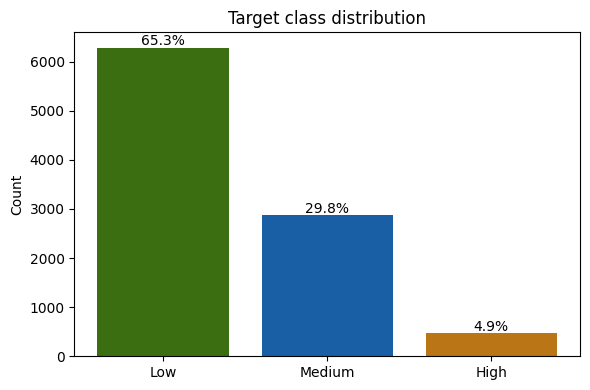

In [8]:
# Target distribution
target_counts = train_df['Target'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index, target_counts.values, color=['#3B6D11','#185FA5','#BA7517'])
ax.set_title('Target class distribution')
ax.set_ylabel('Count')
for i, (label, val) in enumerate(target_counts.items()):
    ax.text(i, val + 50, f'{val/len(train_df)*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

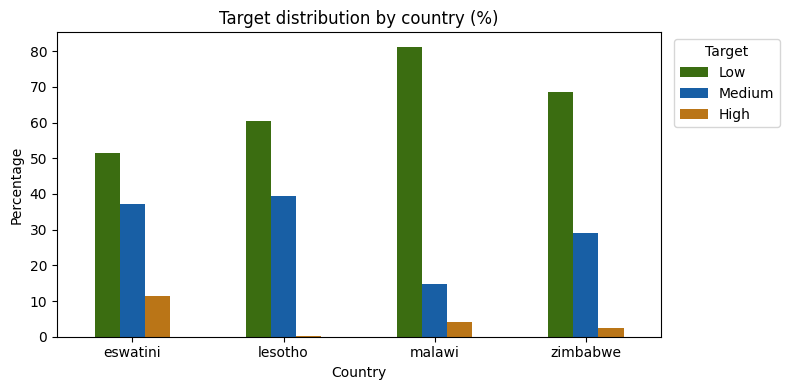

In [9]:
# Define the correct order
target_order = ['Low', 'Medium', 'High']

# Apply ordered categorical BEFORE crosstab
train_df['Target'] = pd.Categorical(train_df['Target'], categories=target_order, ordered=True)

# Target split by country
country_target = pd.crosstab(train_df['country'], train_df['Target'], normalize='index') * 100

country_target = country_target[target_order]  # enforce column order explicitly

country_target.plot(kind='bar', figsize=(8, 4), color=['#3B6D11', '#185FA5', '#BA7517'])
plt.title('Target distribution by country (%)')
plt.ylabel('Percentage')
plt.xlabel('Country')
plt.xticks(rotation=0)
plt.legend(title='Target', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

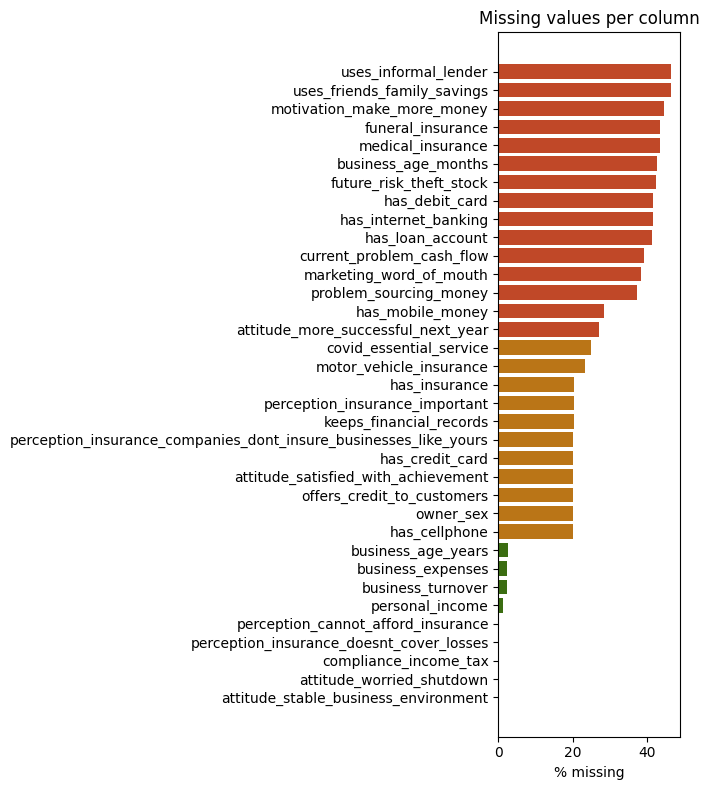

In [10]:
# Missing values heatmap 
miss_pct = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(7, 8))
colors = ['#C04828' if v > 25 else '#BA7517' if v > 5 else '#3B6D11' for v in miss_pct.values]
ax.barh(miss_pct.index, miss_pct.values, color=colors)
ax.set_xlabel('% missing')
ax.set_title('Missing values per column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

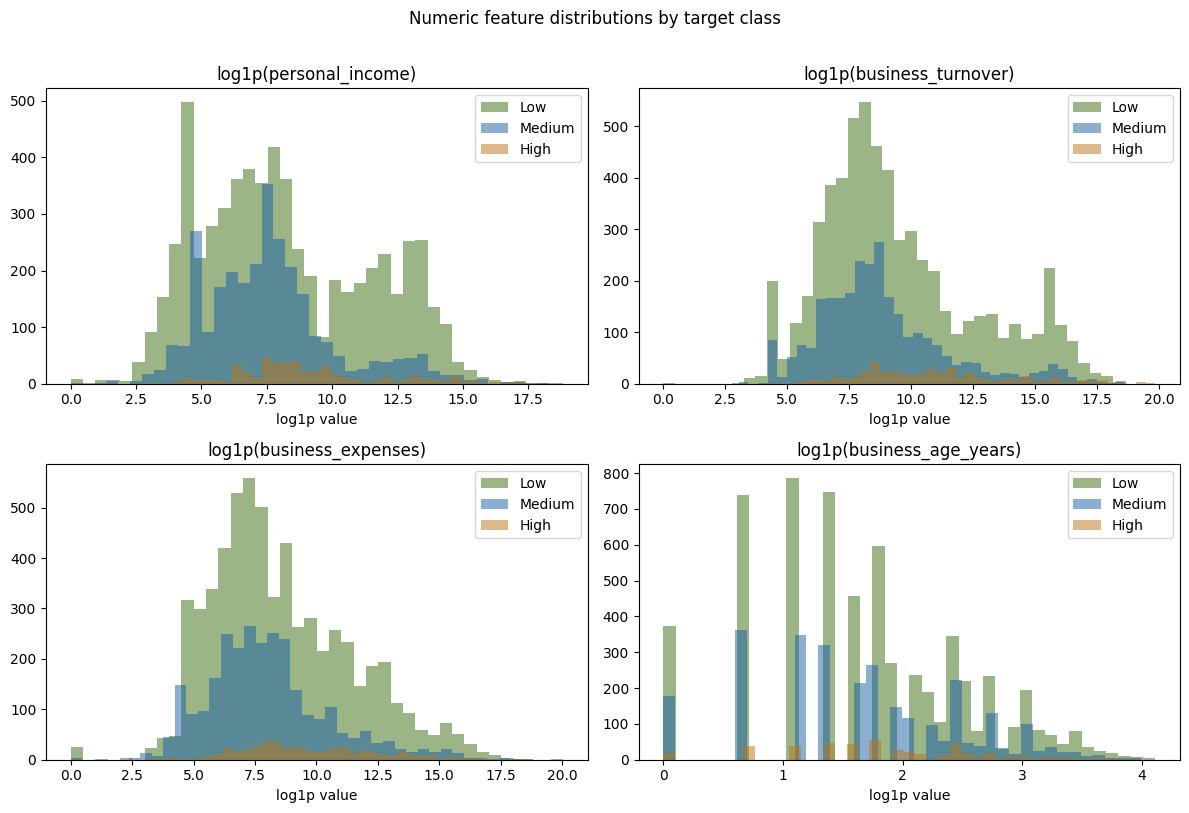

In [11]:
# Numeric distributions per class (log scale)

num_cols = ['personal_income', 'business_turnover', 'business_expenses', 'business_age_years']
colors   = {'Low': '#3B6D11', 'Medium': '#185FA5', 'High': '#BA7517'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for target_class, color in colors.items():
        subset = train_df.loc[train_df['Target'] == target_class, col].dropna()
        log_vals = np.log1p(subset)
        axes[i].hist(log_vals, bins=40, alpha=0.5, label=target_class, color=color)
    axes[i].set_title(f'log1p({col})')
    axes[i].set_xlabel('log1p value')
    axes[i].legend()

plt.suptitle('Numeric feature distributions by target class', y=1.01)
plt.tight_layout()
plt.show()

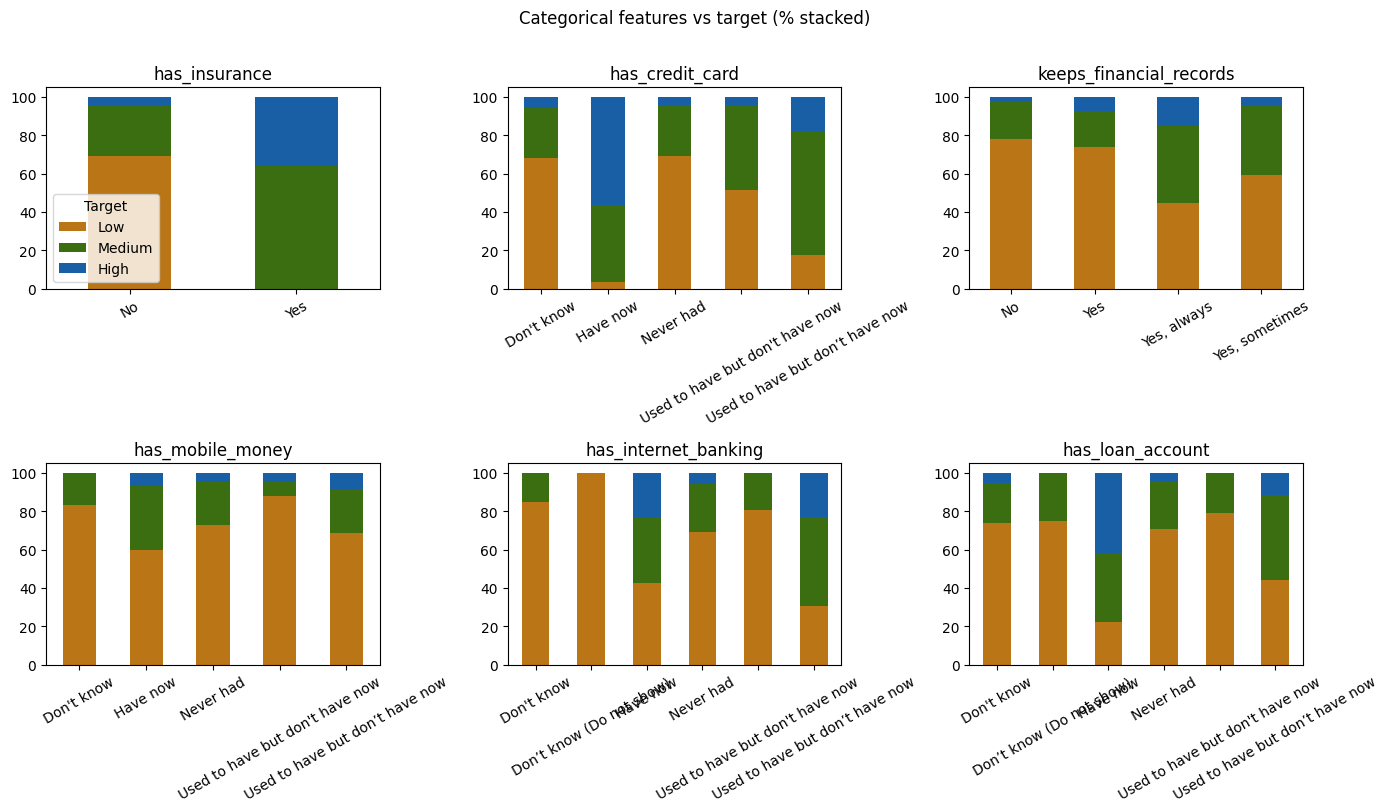

In [12]:
# Categorical features vs target
cat_signal_cols = [
    'has_insurance', 'has_credit_card', 'keeps_financial_records',
    'has_mobile_money', 'has_internet_banking', 'has_loan_account'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_signal_cols):
    ct = pd.crosstab(train_df[col], train_df['Target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#BA7517','#3B6D11','#185FA5'], legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical features vs target (% stacked)', y=1.01)
plt.tight_layout()
plt.show()

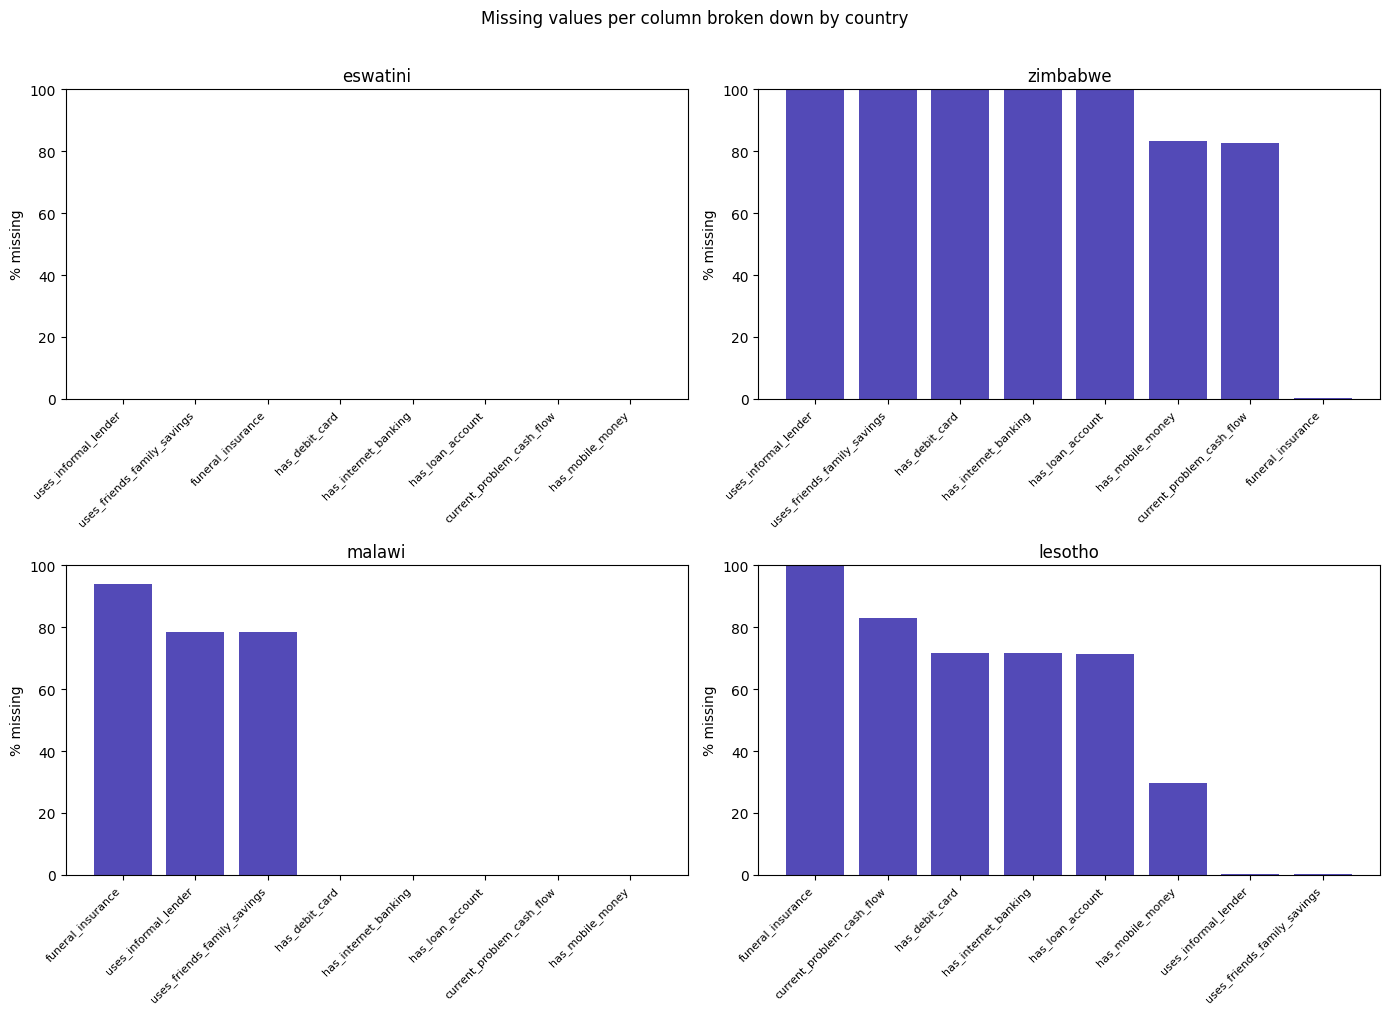

In [13]:
# Missing values by country 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

high_miss_cols = [
    'uses_informal_lender', 'uses_friends_family_savings', 'funeral_insurance',
    'has_debit_card', 'has_internet_banking', 'has_loan_account',
    'current_problem_cash_flow', 'has_mobile_money'
]

for i, country in enumerate(train_df['country'].unique()):
    subset = train_df[train_df['country'] == country][high_miss_cols]
    miss = (subset.isnull().sum() / len(subset) * 100).sort_values(ascending=False)
    axes[i].bar(range(len(miss)), miss.values, color='#534AB7')
    axes[i].set_xticks(range(len(miss)))
    axes[i].set_xticklabels(miss.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(country)
    axes[i].set_ylabel('% missing')
    axes[i].set_ylim(0, 100)

plt.suptitle('Missing values per column broken down by country', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Double stratification shuffle split based on country and target
train_df['strata'] = train_df['country'].astype(str) + '_' + train_df['Target'].astype(str)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

for train_idx, val_idx in sss.split(train_df, train_df['strata']):
    df_train = train_df.iloc[train_idx].drop(columns='strata')
    df_val   = train_df.iloc[val_idx].drop(columns='strata')

X_train = df_train.drop(columns=['Target', 'ID'])
y_train = df_train['Target']
X_val   = df_val.drop(columns=['Target', 'ID'])
y_val   = df_val['Target']

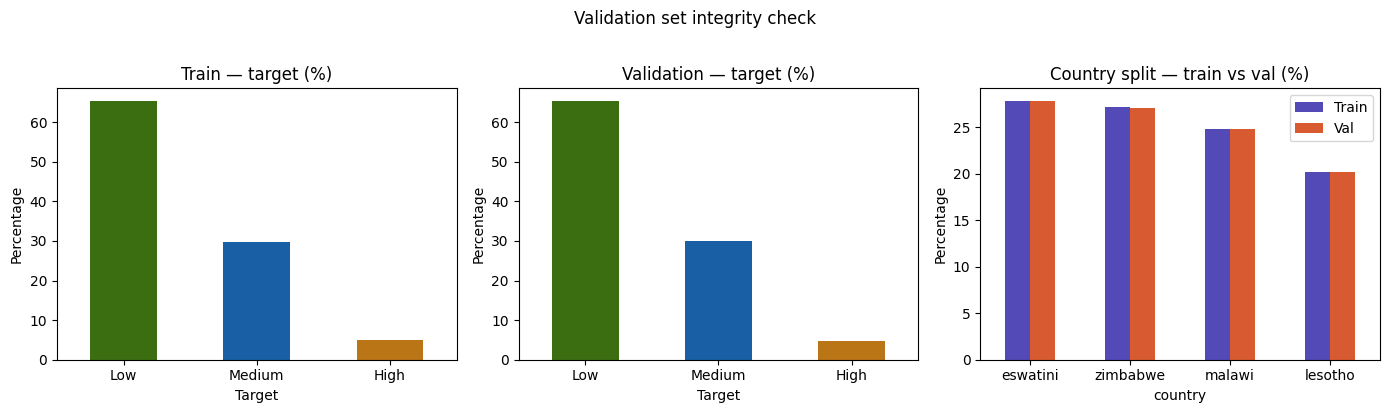

In [15]:
# Verify split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

(y_train.value_counts(normalize=True) * 100).reindex(['Low','Medium','High']).plot(
    kind='bar', ax=axes[0], color=['#3B6D11','#185FA5','#BA7517']
)
axes[0].set_title('Train — target (%)')
axes[0].set_xticklabels(['Low','Medium','High'], rotation=0)

(y_val.value_counts(normalize=True) * 100).reindex(['Low','Medium','High']).plot(
    kind='bar', ax=axes[1], color=['#3B6D11','#185FA5','#BA7517']
)
axes[1].set_title('Validation — target (%)')
axes[1].set_xticklabels(['Low','Medium','High'], rotation=0)

country_check = pd.DataFrame({
    'Train':  df_train['country'].value_counts(normalize=True) * 100,
    'Val':    df_val['country'].value_counts(normalize=True) * 100
}).round(1)
country_check.plot(kind='bar', ax=axes[2], color=['#534AB7','#D85A30'])
axes[2].set_title('Country split — train vs val (%)')
axes[2].set_xticklabels(country_check.index, rotation=0)

for ax in axes:
    ax.set_ylabel('Percentage')

plt.suptitle('Validation set integrity check', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Keep raw copies 
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()

In [17]:
# Unify "Don't know" variants in categorical features
dont_know_variants = [
    "Don't know", "Don?t know", "Don't Know",
    "Don?t know / doesn?t apply", " Do not know / N\u200b/A",
    "Don't know or N/A", "Don't know (Do not show)",
    "Don't know or N/A", "Refused"
]

def unify_unknown(val):
    if pd.isna(val):
        return val
    if str(val).strip() in dont_know_variants or "don" in str(val).lower():
        return "Unknown"
    return val

cat_cols = X_train_raw.select_dtypes(include=['object', 'string']).columns.tolist()

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].apply(unify_unknown)
    X_val_raw[col]   = X_val_raw[col].apply(unify_unknown)

In [18]:
# Unify "No" variants in 'current_problem_cash_flow'
X_train_raw['current_problem_cash_flow'] = X_train_raw['current_problem_cash_flow'].replace('0', 'No')
X_val_raw['current_problem_cash_flow']   = X_val_raw['current_problem_cash_flow'].replace('0', 'No')

In [19]:
# Create missingness indicators for columns with >5% missing values
high_miss_cols = [
    col for col in X_train_raw.columns
    if X_train_raw[col].isnull().mean() > 0.05
]

for col in high_miss_cols:
    X_train_raw[f'{col}_was_missing'] = X_train_raw[col].isnull().astype(int)
    X_val_raw[f'{col}_was_missing']   = X_val_raw[col].isnull().astype(int)

In [20]:
# Impute missing values
num_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object', 'string']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
X_train_raw[num_cols] = num_imputer.fit_transform(X_train_raw[num_cols])
X_val_raw[num_cols]   = num_imputer.transform(X_val_raw[num_cols])

cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
X_train_raw[cat_cols] = cat_imputer.fit_transform(X_train_raw[cat_cols])
X_val_raw[cat_cols]   = cat_imputer.transform(X_val_raw[cat_cols])

In [21]:
# Create total business age in months and drop original year/month columns
X_train_raw['business_age_total_months'] = (
    X_train_raw['business_age_years'] * 12 + X_train_raw['business_age_months']
)
X_val_raw['business_age_total_months'] = (
    X_val_raw['business_age_years'] * 12 + X_val_raw['business_age_months']
)

X_train_raw.drop(columns=['business_age_years', 'business_age_months'], inplace=True)
X_val_raw.drop(columns=['business_age_years', 'business_age_months'], inplace=True)

In [22]:
# Standardize numeric features
cat_cols_final = X_train_raw.select_dtypes(include=['object', 'string']).columns.tolist()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train_raw[cat_cols_final])
ohe_val   = ohe.transform(X_val_raw[cat_cols_final])

ohe_feature_names = ohe.get_feature_names_out(cat_cols_final)

ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train_raw.index)
ohe_val_df   = pd.DataFrame(ohe_val,   columns=ohe_feature_names, index=X_val_raw.index)

In [23]:
# Drop original categorical columns and concatenate one-hot encoded columns
skewed_num_cols = ['personal_income', 'business_expenses', 'business_turnover']

for col in skewed_num_cols:
    X_train_raw[col] = np.log1p(X_train_raw[col])
    X_val_raw[col]   = np.log1p(X_val_raw[col])

In [24]:
# Drop original categorical columns
num_cols_final = X_train_raw.select_dtypes(include='number').columns.tolist()

scaler = StandardScaler()
X_train_raw[num_cols_final] = scaler.fit_transform(X_train_raw[num_cols_final])
X_val_raw[num_cols_final]   = scaler.transform(X_val_raw[num_cols_final])

In [25]:
# Concatenate numeric and one-hot encoded features
X_train_num = X_train_raw[num_cols_final].reset_index(drop=True)
X_val_num   = X_val_raw[num_cols_final].reset_index(drop=True)

ohe_train_df = ohe_train_df.reset_index(drop=True)
ohe_val_df   = ohe_val_df.reset_index(drop=True)

X_train_final = pd.concat([X_train_num, ohe_train_df], axis=1)
X_val_final   = pd.concat([X_val_num,   ohe_val_df],   axis=1)

y_train_final = y_train.reset_index(drop=True)
y_val_final   = y_val.reset_index(drop=True)

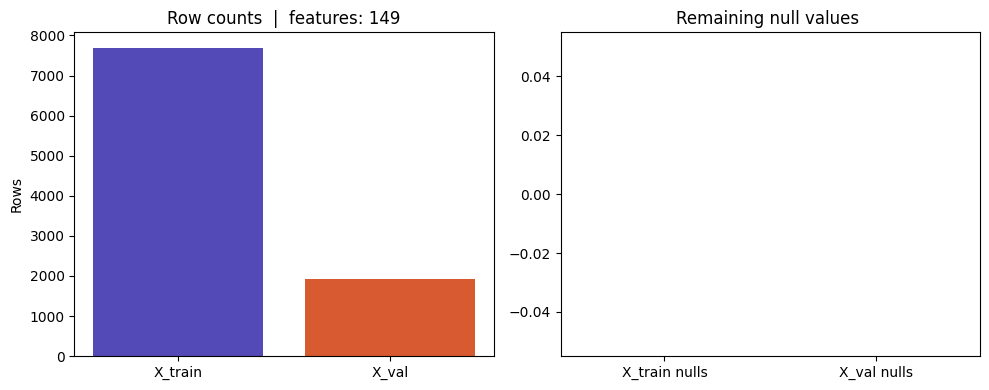

In [26]:
# Final checks
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ['X_train', 'X_val'],
    [X_train_final.shape[0], X_val_final.shape[0]],
    color=['#534AB7', '#D85A30']
)
axes[0].set_title(f'Row counts  |  features: {X_train_final.shape[1]}')
axes[0].set_ylabel('Rows')

null_counts = [X_train_final.isnull().sum().sum(), X_val_final.isnull().sum().sum()]
axes[1].bar(['X_train nulls', 'X_val nulls'], null_counts, color=['#3B6D11','#3B6D11'])
axes[1].set_title('Remaining null values ')

plt.tight_layout()
plt.show()

In [27]:
# Logistic Regression baseline
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    C=1.0
)

lr.fit(X_train_final, y_train_final)

y_train_pred_lr = lr.predict(X_train_final)
y_val_pred_lr   = lr.predict(X_val_final)

f1_train_lr = f1_score(y_train_final, y_train_pred_lr, average='macro')
f1_val_lr   = f1_score(y_val_final,   y_val_pred_lr,   average='macro')

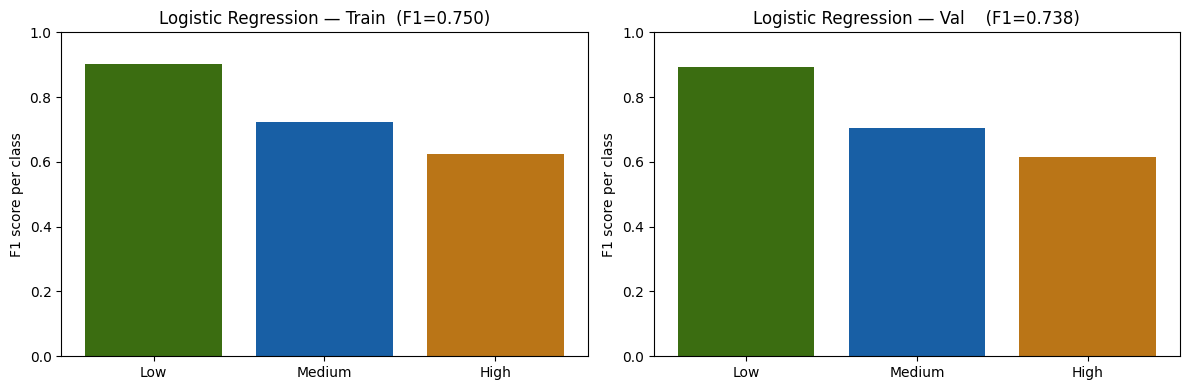

In [28]:
# Detailed classification report with F1 scores per class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_final, y_val_final],
    [y_train_pred_lr, y_val_pred_lr],
    [f'Logistic Regression — Train  (F1={f1_train_lr:.3f})',
     f'Logistic Regression — Val    (F1={f1_val_lr:.3f})']
):
    report = classification_report(y_true, y_pred, output_dict=True)
    classes = ['Low', 'Medium', 'High']
    f1_scores = [report[c]['f1-score'] for c in classes]
    ax.bar(classes, f1_scores, color=['#3B6D11','#185FA5','#BA7517'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score per class')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [29]:
# Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_final)

y_train_pred_rf = rf.predict(X_train_final)
y_val_pred_rf   = rf.predict(X_val_final)

f1_train_rf = f1_score(y_train_final, y_train_pred_rf, average='macro')
f1_val_rf   = f1_score(y_val_final,   y_val_pred_rf,   average='macro')

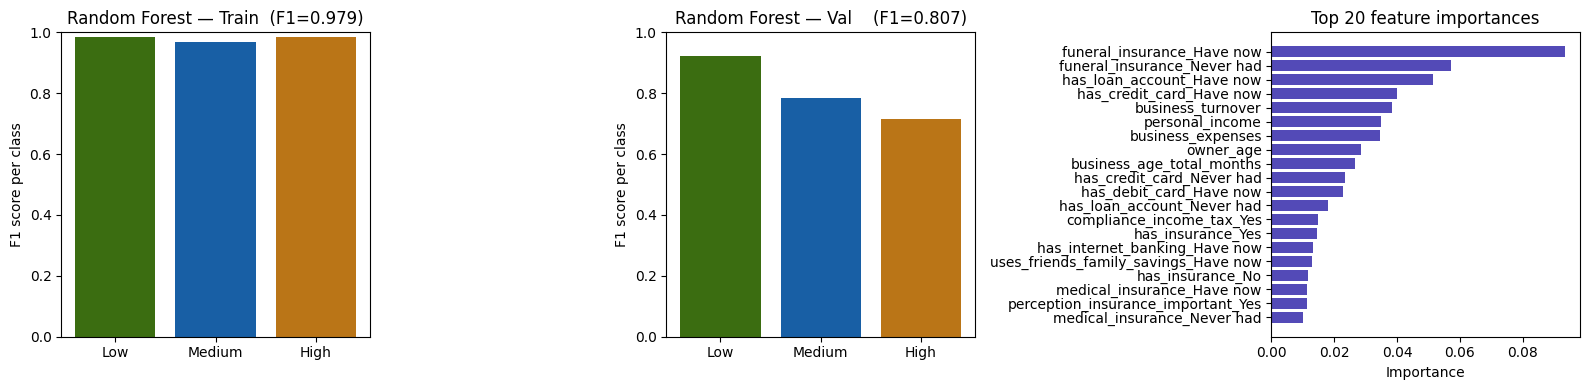

In [30]:
# Detailed classification report with F1 scores per class and feature
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_true, y_pred, title in zip(
    axes[:2],
    [y_train_final, y_val_final],
    [y_train_pred_rf, y_val_pred_rf],
    [f'Random Forest — Train  (F1={f1_train_rf:.3f})',
     f'Random Forest — Val    (F1={f1_val_rf:.3f})']
):
    report = classification_report(y_true, y_pred, output_dict=True)
    classes = ['Low', 'Medium', 'High']
    f1_scores = [report[c]['f1-score'] for c in classes]
    ax.bar(classes, f1_scores, color=['#3B6D11','#185FA5','#BA7517'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score per class')
    ax.set_title(title)

importances = pd.Series(rf.feature_importances_, index=X_train_final.columns)
top20 = importances.nlargest(20)
axes[2].barh(top20.index[::-1], top20.values[::-1], color='#534AB7')
axes[2].set_title('Top 20 feature importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [31]:
# LightGBM Classifier with early stopping and detailed classification report

# Use NumPy arrays to avoid LightGBM feature-name JSON character issues
X_train_lgbm = X_train_final.to_numpy(dtype=np.float32)
X_val_lgbm   = X_val_final.to_numpy(dtype=np.float32)

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train_lgbm, y_train_final,
    eval_set=[(X_val_lgbm, y_val_final)],
    callbacks=[early_stopping(stopping_rounds=50, verbose=False),
               log_evaluation(period=-1)]
)

y_train_pred_lgbm = lgbm.predict(X_train_lgbm)
y_val_pred_lgbm   = lgbm.predict(X_val_lgbm)

f1_train_lgbm = f1_score(y_train_final, y_train_pred_lgbm, average='macro')
f1_val_lgbm   = f1_score(y_val_final,   y_val_pred_lgbm,   average='macro')

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


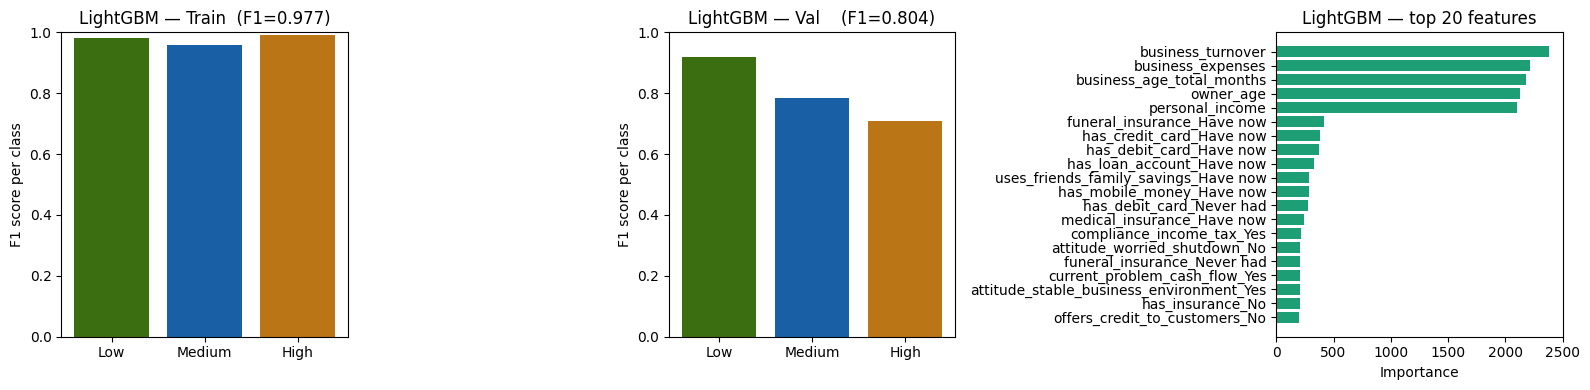

In [32]:
# Detailed classification report with F1 scores per class and feature
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_true, y_pred, title in zip(
    axes[:2],
    [y_train_final, y_val_final],
    [y_train_pred_lgbm, y_val_pred_lgbm],
    [f'LightGBM — Train  (F1={f1_train_lgbm:.3f})',
     f'LightGBM — Val    (F1={f1_val_lgbm:.3f})']
):
    report = classification_report(y_true, y_pred, output_dict=True)
    classes = ['Low', 'Medium', 'High']
    f1_scores = [report[c]['f1-score'] for c in classes]
    ax.bar(classes, f1_scores, color=['#3B6D11','#185FA5','#BA7517'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score per class')
    ax.set_title(title)

importances = pd.Series(lgbm.feature_importances_, index=X_train_final.columns)
top20 = importances.nlargest(20)
axes[2].barh(top20.index[::-1], top20.values[::-1], color='#1D9E75')
axes[2].set_title('LightGBM — top 20 features')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [33]:
# XGBoost Classifier with early stopping and detailed classification report

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_final)

label_map  = {'Low': 0, 'Medium': 1, 'High': 2}
label_map_inv = {v: k for k, v in label_map.items()}

y_train_enc = y_train_final.map(label_map)
y_val_enc   = y_val_final.map(label_map)

xgb.fit(
    X_train_final, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val_final, y_val_enc)],
    verbose=False
)

y_train_pred_xgb = pd.Series(xgb.predict(X_train_final)).map(label_map_inv)
y_val_pred_xgb   = pd.Series(xgb.predict(X_val_final)).map(label_map_inv)

f1_train_xgb = f1_score(y_train_final, y_train_pred_xgb, average='macro')
f1_val_xgb   = f1_score(y_val_final,   y_val_pred_xgb,   average='macro')

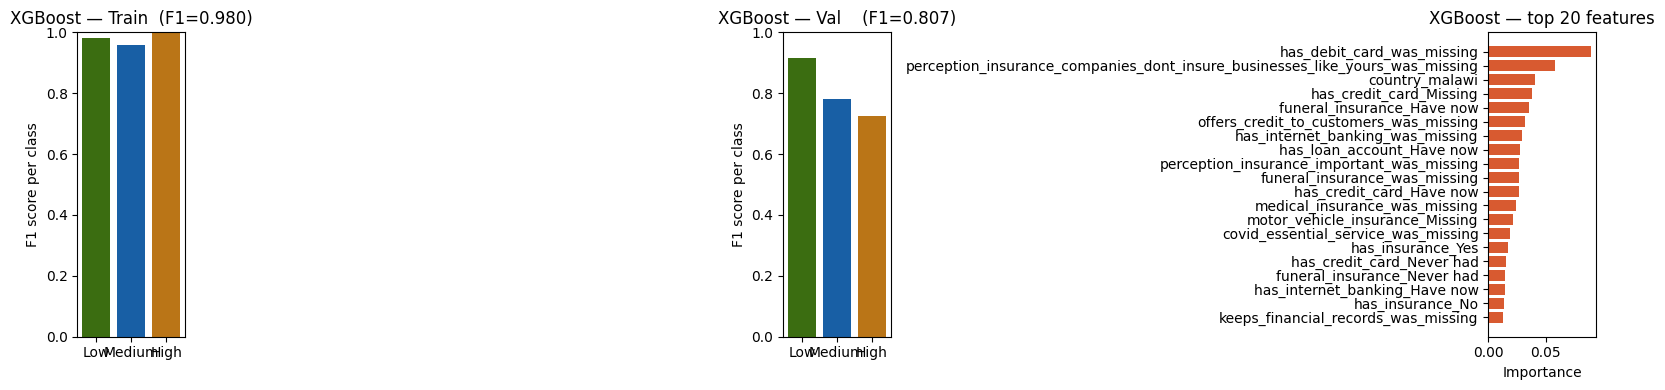

In [34]:
# Detailed classification report with F1 scores per class and feature
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_true, y_pred, title in zip(
    axes[:2],
    [y_train_final, y_val_final],
    [y_train_pred_xgb, y_val_pred_xgb],
    [f'XGBoost — Train  (F1={f1_train_xgb:.3f})',
     f'XGBoost — Val    (F1={f1_val_xgb:.3f})']
):
    report = classification_report(y_true, y_pred, output_dict=True)
    classes = ['Low', 'Medium', 'High']
    f1_scores = [report[c]['f1-score'] for c in classes]
    ax.bar(classes, f1_scores, color=['#3B6D11','#185FA5','#BA7517'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score per class')
    ax.set_title(title)

importances = pd.Series(xgb.feature_importances_, index=X_train_final.columns)
top20 = importances.nlargest(20)
axes[2].barh(top20.index[::-1], top20.values[::-1], color='#D85A30')
axes[2].set_title('XGBoost — top 20 features')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

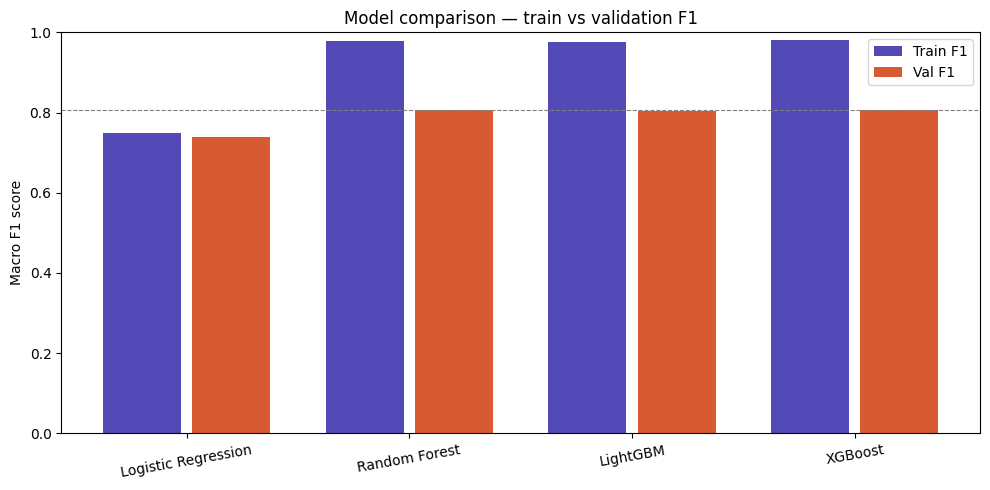

In [35]:

# Summary comparison of all models
results = {
    'Logistic Regression': (f1_train_lr,   f1_val_lr),
    'Random Forest':       (f1_train_rf,   f1_val_rf),
    'LightGBM':            (f1_train_lgbm, f1_val_lgbm),
    'XGBoost':             (f1_train_xgb,  f1_val_xgb),
}

names       = list(results.keys())
train_f1s   = [results[m][0] for m in names]
val_f1s     = [results[m][1] for m in names]
x           = range(len(names))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], train_f1s, width=0.35, label='Train F1', color='#534AB7')
ax.bar([i + 0.2 for i in x], val_f1s,   width=0.35, label='Val F1',   color='#D85A30')
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1 score')
ax.set_title('Model comparison — train vs validation F1')
ax.legend()
ax.axhline(y=max(val_f1s), color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [36]:
# Ordinal mapping for finance product ownership and yes/no questions
FINANCE_PRODUCT_MAP = {
    "Have now": 3,
    "Used to have but don't have now": 2,
    "Never had": 1,
    "Don't know": np.nan, "Don't Know": np.nan, "Unknown": np.nan, "Missing": np.nan,
}
YESNO_MAP = {
    "Yes": 1, "Yes, always": 1, "Yes, sometimes": 0.5,
    "No": 0, "0": 0,
    "Don't know or N/A": np.nan, "Unknown": np.nan, "Missing": np.nan, "Refused": np.nan,
}
FINANCE_PRODUCT_COLS = [
    "motor_vehicle_insurance", "has_mobile_money", "has_credit_card", "has_loan_account",
    "has_internet_banking", "has_debit_card", "medical_insurance", "funeral_insurance",
    "uses_friends_family_savings", "uses_informal_lender",
]
YESNO_COLS = [
    "attitude_stable_business_environment", "attitude_worried_shutdown", "compliance_income_tax",
    "perception_insurance_doesnt_cover_losses", "perception_cannot_afford_insurance",
    "current_problem_cash_flow", "has_cellphone", "attitude_satisfied_with_achievement",
    "perception_insurance_companies_dont_insure_businesses_like_yours",
    "perception_insurance_important", "has_insurance", "covid_essential_service",
    "attitude_more_successful_next_year", "problem_sourcing_money", "marketing_word_of_mouth",
    "future_risk_theft_stock", "motivation_make_more_money", "offers_credit_to_customers",
    "keeps_financial_records",
]

def apply_ordinal_maps(df):
    out = df.copy()
    for col in FINANCE_PRODUCT_COLS:
        if col in out.columns:
            out[col] = out[col].astype(str).str.strip().map(FINANCE_PRODUCT_MAP)
    for col in YESNO_COLS:
        if col in out.columns:
            out[col] = out[col].astype(str).str.strip().map(YESNO_MAP)
    return out

df_train_v2 = apply_ordinal_maps(df_train.copy())
df_val_v2   = apply_ordinal_maps(df_val.copy())

In [37]:
# Feature engineering function to create new features based on domain knowledge and interactions
def engineer_features(df):
    out = df.copy()

    # financial ratios
    out["gross_margin"]         = out["business_turnover"] - out["business_expenses"]
    out["expense_to_turnover"]  = out["business_expenses"] / (out["business_turnover"] + 1e-6)
    out["fe_profit_margin"]     = out["gross_margin"] / (out["business_turnover"] + 1e-6)
    out["income_to_turnover"]   = out["personal_income"] / (out["business_turnover"] + 1e-6)
    out["operational_profitability_margin"] = out["gross_margin"] / (out["business_turnover"].fillna(0) + 1e-9)

    # combined business age
    out["business_age_total_months"] = out["business_age_years"].fillna(0) * 12 + out["business_age_months"].fillna(0)
    out["business_age_total_years"]  = out["business_age_total_months"] / 12.0
    out["turnover_per_year"]  = out["business_turnover"] / (out["business_age_total_years"] + 0.5)
    out["expenses_per_year"]  = out["business_expenses"] / (out["business_age_total_years"] + 0.5)

    # log transforms
    for col in ["personal_income", "business_expenses", "business_turnover", "gross_margin"]:
        out[f"log1p_{col}"] = np.log1p(out[col].clip(lower=0).fillna(0))

    # financial access score (mean of formal product ownership)
    formal_cols = ["has_mobile_money", "has_credit_card", "has_loan_account",
                   "has_internet_banking", "has_debit_card", "medical_insurance",
                   "funeral_insurance", "has_insurance"]
    formal_cols = [c for c in formal_cols if c in out.columns]
    scores = out[formal_cols].apply(lambda col: col.replace({3: 1.0, 2: 0.5, 1: 0.0}))
    n_valid = scores.notna().sum(axis=1)
    out["financial_access_score"] = np.where(n_valid > 0, scores.sum(axis=1) / n_valid, np.nan)

    # informal access score
    informal_cols = [c for c in ["uses_friends_family_savings", "uses_informal_lender"] if c in out.columns]
    inf_scores = out[informal_cols].apply(lambda col: col.replace({3: 1.0, 2: 0.5, 1: 0.0}))
    n_inf = inf_scores.notna().sum(axis=1)
    out["informal_access_score"] = np.where(n_inf > 0, inf_scores.sum(axis=1) / n_inf, np.nan)

    # stress score
    stress = pd.Series(0.0, index=out.index)
    for col in ["attitude_worried_shutdown", "current_problem_cash_flow", "problem_sourcing_money"]:
        if col in out.columns:
            stress += out[col].fillna(0)
    out["stress_score"] = stress

    # count of products currently held
    now_cols = ["has_mobile_money", "has_credit_card", "has_loan_account",
                "has_internet_banking", "has_debit_card"]
    now_cols = [c for c in now_cols if c in out.columns]
    out["num_products_have_now"] = (out[now_cols] == 3).sum(axis=1)

    # interactions
    out["owner_business_age_interaction"] = out["owner_age"].fillna(0) * out["business_age_total_years"].fillna(0)
    out["stress_x_expense_ratio"]         = out["stress_score"] * out["expense_to_turnover"].clip(0, 5).fillna(0)
    out["access_x_log_turnover"]          = out["financial_access_score"].fillna(0) * np.log1p(out["business_turnover"].clip(lower=0).fillna(0))
    out["credit_access_vulnerability"]    = (1 - out["financial_access_score"].fillna(0)) * (0.5 + out["informal_access_score"].fillna(0))

    # rule-based bin (heuristic feature, not target)
    profit_ok = out["fe_profit_margin"].fillna(0) >= 0.1
    acc       = out["financial_access_score"].fillna(0)
    stress    = out["stress_score"].fillna(0)
    high      = (acc >= 0.5) & (stress <= 1) & profit_ok
    medium    = ((acc >= 0.3) & (stress <= 2)) | ((acc >= 0.2) & (stress <= 1))
    rule_bin  = np.zeros(len(out), dtype=int)
    rule_bin[medium & ~high] = 1
    rule_bin[high] = 2
    out["fhi_rule_bin"] = rule_bin

    return out

df_train_v2 = engineer_features(df_train_v2)
df_val_v2   = engineer_features(df_val_v2)

In [38]:
# Country-level scaling and percentile features for key financial columns
FIN_COLS = ["personal_income", "business_expenses", "business_turnover"]

def fit_country_scale_params(train, cols):
    params = {}
    for col in cols:
        if col not in train.columns:
            continue
        log_vals = np.log1p(train[col].clip(lower=0).fillna(0))
        grp = train.assign(_l=log_vals).groupby("country")["_l"].agg(["mean", "std"])
        grp["std"] = grp["std"].replace(0, np.nan).fillna(1.0)
        params[col] = grp.to_dict("index")
    return params

def apply_country_scale(df, params):
    out = df.copy()
    for col, country_stats in params.items():
        log_vals = np.log1p(out[col].clip(lower=0).fillna(0))
        out[f"{col}_country_scaled"] = np.nan
        for country, stats in country_stats.items():
            mask = out["country"].astype(str).str.lower() == str(country).lower()
            out.loc[mask, f"{col}_country_scaled"] = (log_vals[mask] - stats["mean"]) / (stats["std"] + 1e-9)
    return out

def fit_country_pct_params(train, cols):
    params = {}
    for col in cols:
        params[col] = {}
        for country in train["country"].dropna().unique():
            vals = train.loc[train["country"] == country, col].dropna().values
            params[col][str(country)] = vals
    return params

def apply_country_pct(df, params, is_train=False):
    out = df.copy()
    for col, country_vals in params.items():
        out[f"{col}_country_pct"] = np.nan
        for country, train_vals in country_vals.items():
            if len(train_vals) == 0:
                continue
            mask = out["country"].astype(str) == str(country)
            if is_train:
                out.loc[mask, f"{col}_country_pct"] = out.loc[mask, col].rank(pct=True).values
            else:
                for idx in out.index[mask]:
                    v = out.loc[idx, col]
                    if pd.notna(v):
                        out.loc[idx, f"{col}_country_pct"] = percentileofscore(train_vals, float(v), kind="rank") / 100.0
    return out

scale_params = fit_country_scale_params(df_train_v2, FIN_COLS)
pct_params   = fit_country_pct_params(df_train_v2, FIN_COLS)

df_train_v2 = apply_country_scale(df_train_v2, scale_params)
df_train_v2 = apply_country_pct(df_train_v2, pct_params, is_train=True)
df_val_v2   = apply_country_scale(df_val_v2, scale_params)
df_val_v2   = apply_country_pct(df_val_v2, pct_params, is_train=False)

In [39]:
# Prepare data for modeling with new features and pipelines
X_tr = df_train_v2.drop(columns=["ID", "Target"])
y_tr = df_train_v2["Target"]
X_vl = df_val_v2.drop(columns=["ID", "Target"]).reindex(columns=X_tr.columns, fill_value=np.nan)
y_vl = df_val_v2["Target"]

num_cols_v2 = X_tr.select_dtypes(include="number").columns.tolist()
cat_cols_v2 = X_tr.select_dtypes(include="object").columns.tolist()

num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler",  StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="<MISSING>")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor_v2 = ColumnTransformer([
    ("num", num_pipe, num_cols_v2),
    ("cat", cat_pipe, cat_cols_v2)
])

LGB_PARAMS = {
    "n_estimators": 494, "max_depth": 6, "num_leaves": 136,
    "min_child_samples": 86, "learning_rate": 0.019, "reg_lambda": 0.0094,
    "class_weight": "balanced", "random_state": SEED, "verbose": -1, "n_jobs": -1
}
XGB_PARAMS = {
    "n_estimators": 534, "max_depth": 5, "learning_rate": 0.010,
    "subsample": 0.726, "colsample_bytree": 0.631,
    "reg_alpha": 1.64, "reg_lambda": 1.76,
    "random_state": SEED, "verbosity": 0, "n_jobs": -1
}
HGB_PARAMS = {
    "max_iter": 328, "max_depth": 10, "min_samples_leaf": 24,
    "learning_rate": 0.019, "l2_regularization": 0.092,
    "max_bins": 133, "random_state": SEED
}

ensemble = VotingClassifier(estimators=[
    ("lgb", LGBMClassifier(**LGB_PARAMS)),
    ("xgb", XGBClassifier(**XGB_PARAMS)),
    ("hgb", HistGradientBoostingClassifier(**HGB_PARAMS)),
], voting="soft")

calibrated = CalibratedClassifierCV(ensemble, cv=3, method="isotonic")

pipe_v2 = ImbPipeline([
    ("pre",   preprocessor_v2),
    ("smote", SMOTE(random_state=SEED)),
    ("clf",   calibrated)
])

pipe_v2.fit(X_tr, y_tr)

y_val_pred_v2  = pipe_v2.predict(X_vl)
f1_val_v2      = f1_score(y_vl, y_val_pred_v2, average="macro")

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-pack

In [40]:
# Train country-specific models for countries with enough data and variability
country_pipes = {}
for country in X_tr["country"].dropna().unique():
    mask = X_tr["country"] == country
    X_c, y_c = X_tr.loc[mask], y_tr.loc[mask]

    if len(y_c) < 15 or y_c.nunique() < 2:
        country_pipes[country] = pipe_v2
    else:
        pipe_c = clone(pipe_v2)

        # SMOTE needs k_neighbors <= (minority_class_count - 1)
        min_class_count = y_c.value_counts().min()
        if min_class_count <= 1:
            pipe_c.set_params(smote="passthrough")
        else:
            pipe_c.set_params(smote__k_neighbors=min(5, int(min_class_count) - 1))

        pipe_c.fit(X_c, y_c)
        country_pipes[country] = pipe_c

# blended val prediction using country-specific models
y_val_pred_country = y_val_pred_v2.copy()
for country, pipe_c in country_pipes.items():
    mask = X_vl["country"] == country
    if mask.sum() > 0:
        preds = pipe_c.predict(X_vl.loc[mask])
        y_val_pred_country[mask.values] = preds

f1_val_country = f1_score(y_vl, y_val_pred_country, average="macro")

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-pack

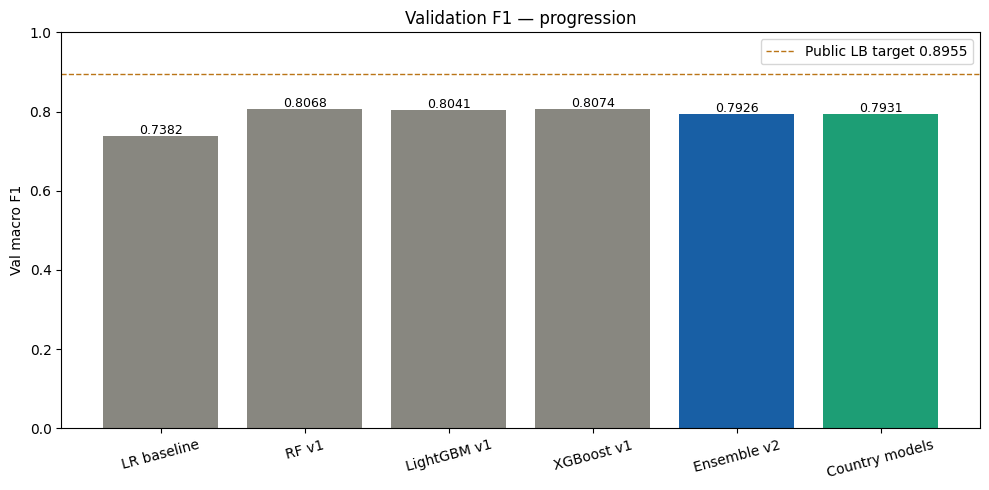

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

approaches = ["LR baseline", "RF v1", "LightGBM v1", "XGBoost v1", "Ensemble v2", "Country models"]
val_scores = [f1_val_lr, f1_val_rf, f1_val_lgbm, f1_val_xgb, f1_val_v2, f1_val_country]
colors     = ["#888780","#888780","#888780","#888780","#185FA5","#1D9E75"]

bars = ax.bar(approaches, val_scores, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Val macro F1")
ax.set_title("Validation F1 — progression")
ax.axhline(0.8955, color="#BA7517", linestyle="--", linewidth=1, label="Public LB target 0.8955")
ax.legend()
for bar, val in zip(bars, val_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}", ha="center", fontsize=9)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [42]:
# Predict on Zindi test set (use the trained v2 pipeline)
df_test_v2 = apply_ordinal_maps(test_df.copy())
df_test_v2 = engineer_features(df_test_v2)
df_test_v2 = apply_country_scale(df_test_v2, scale_params)
df_test_v2 = apply_country_pct(df_test_v2, pct_params, is_train=False)

X_test = df_test_v2.drop(columns=["ID"]).reindex(columns=X_tr.columns, fill_value=np.nan)
predictions = pipe_v2.predict(X_test)

# Create submission dataframe
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Target': predictions
})

# Save
submission.to_csv('submission.csv', index=False)
print(submission.shape)
submission.head()

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(2405, 2)


,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Medium
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


In [45]:
def objective(trial):
    lgb_params = {
        "n_estimators":      trial.suggest_int("lgb_n_estimators", 300, 700),
        "max_depth":         trial.suggest_int("lgb_max_depth", 4, 10),
        "num_leaves":        trial.suggest_int("lgb_num_leaves", 31, 255),
        "min_child_samples": trial.suggest_int("lgb_min_child_samples", 10, 100),
        "learning_rate":     trial.suggest_float("lgb_lr", 0.005, 0.05, log=True),
        "reg_lambda":        trial.suggest_float("lgb_reg_lambda", 1e-3, 1.0, log=True),
        "subsample":         trial.suggest_float("lgb_subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("lgb_colsample", 0.6, 1.0),
        "class_weight": "balanced", "random_state": SEED, "verbose": -1, "n_jobs": 1
    }
    xgb_params = {
        "n_estimators":     trial.suggest_int("xgb_n_estimators", 300, 700),
        "max_depth":        trial.suggest_int("xgb_max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("xgb_lr", 0.005, 0.05, log=True),
        "subsample":        trial.suggest_float("xgb_subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("xgb_colsample", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("xgb_alpha", 0.1, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("xgb_lambda", 0.1, 5.0, log=True),
        "random_state": SEED, "verbosity": 0, "n_jobs": 1
    }
    hgb_params = {
        "max_iter":           trial.suggest_int("hgb_max_iter", 200, 500),
        "max_depth":          trial.suggest_int("hgb_max_depth", 4, 12),
        "min_samples_leaf":   trial.suggest_int("hgb_min_samples_leaf", 10, 50),
        "learning_rate":      trial.suggest_float("hgb_lr", 0.005, 0.05, log=True),
        "l2_regularization":  trial.suggest_float("hgb_l2", 1e-3, 1.0, log=True),
        "max_bins":           trial.suggest_int("hgb_max_bins", 64, 255),
        "random_state": SEED
    }

    # Lighter preprocessor for CV tuning (avoid KNNImputer O(n^2) memory blow-up)
    pre_tune = clone(preprocessor_v2)
    pre_tune.set_params(num__imputer=SimpleImputer(strategy="median"))

    ensemble_trial = VotingClassifier(estimators=[
        ("lgb", LGBMClassifier(**lgb_params)),
        ("xgb", XGBClassifier(**xgb_params)),
        ("hgb", HistGradientBoostingClassifier(**hgb_params)),
    ], voting="soft")

    pipe_trial = ImbPipeline([
        ("pre",   pre_tune),
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   ensemble_trial)
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = cross_val_score(c
        pipe_trial,
        X_tr,
        y_tr,
        cv=cv,
        scoring="f1_macro",
        n_jobs=1,
        error_score="raise"
    )
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\P

[W 2026-03-15 13:00:00,413] Trial 18 failed with parameters: {'lgb_n_estimators': 645, 'lgb_max_depth': 9, 'lgb_num_leaves': 126, 'lgb_min_child_samples': 63, 'lgb_lr': 0.03726214615341115, 'lgb_reg_lambda': 0.017801088162957036, 'lgb_subsample': 0.6913304870429707, 'lgb_colsample': 0.9331405168302014, 'xgb_n_estimators': 627, 'xgb_max_depth': 8, 'xgb_lr': 0.012480995906580528, 'xgb_subsample': 0.8117106650995927, 'xgb_colsample': 0.7742975358851714, 'xgb_alpha': 0.3028556795176817, 'xgb_lambda': 0.20863568568751598, 'hgb_max_iter': 338, 'hgb_max_depth': 12, 'hgb_min_samples_leaf': 47, 'hgb_lr': 0.016507828999319057, 'hgb_l2': 0.025526698912229997, 'hgb_max_bins': 132} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Administrator\AppDa

KeyboardInterrupt: 

In [ ]:
best = study.best_params

LGB_TUNED = {
    "n_estimators": best["lgb_n_estimators"], "max_depth": best["lgb_max_depth"],
    "num_leaves": best["lgb_num_leaves"], "min_child_samples": best["lgb_min_child_samples"],
    "learning_rate": best["lgb_lr"], "reg_lambda": best["lgb_reg_lambda"],
    "subsample": best["lgb_subsample"], "colsample_bytree": best["lgb_colsample"],
    "class_weight": "balanced", "random_state": SEED, "verbose": -1, "n_jobs": -1
}
XGB_TUNED = {
    "n_estimators": best["xgb_n_estimators"], "max_depth": best["xgb_max_depth"],
    "learning_rate": best["xgb_lr"], "subsample": best["xgb_subsample"],
    "colsample_bytree": best["xgb_colsample"], "reg_alpha": best["xgb_alpha"],
    "reg_lambda": best["xgb_lambda"], "random_state": SEED, "verbosity": 0, "n_jobs": -1
}
HGB_TUNED = {
    "max_iter": best["hgb_max_iter"], "max_depth": best["hgb_max_depth"],
    "min_samples_leaf": best["hgb_min_samples_leaf"], "learning_rate": best["hgb_lr"],
    "l2_regularization": best["hgb_l2"], "max_bins": best["hgb_max_bins"],
    "random_state": SEED
}

ensemble_tuned = VotingClassifier(estimators=[
    ("lgb", LGBMClassifier(**LGB_TUNED)),
    ("xgb", XGBClassifier(**XGB_TUNED)),
    ("hgb", HistGradientBoostingClassifier(**HGB_TUNED)),
], voting="soft")

pipe_tuned = ImbPipeline([
    ("pre",   clone(preprocessor_v2)),
    ("smote", SMOTE(random_state=SEED)),
    ("clf",   CalibratedClassifierCV(ensemble_tuned, cv=3, method="isotonic"))
])

pipe_tuned.fit(X_tr, y_tr)

f1_tuned = f1_score(y_vl, pipe_tuned.predict(X_vl), average="macro")

In [ ]:
proba_val = pipe_tuned.predict_proba(X_vl)
classes   = pipe_tuned.named_steps["clf"].classes_
high_idx  = list(classes).index("High")

thresholds = np.arange(0.10, 0.50, 0.02)
thresh_f1s = []

for t in thresholds:
    preds = []
    for row in proba_val:
        if row[high_idx] >= t:
            preds.append("High")
        else:
            preds.append(classes[np.argmax(row)])
    thresh_f1s.append(f1_score(y_vl, preds, average="macro"))

best_thresh = thresholds[np.argmax(thresh_f1s)]
f1_thresh   = max(thresh_f1s)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, thresh_f1s, color="#185FA5", marker="o", markersize=4)
ax.axvline(best_thresh, color="#BA7517", linestyle="--", label=f"Best threshold = {best_thresh:.2f}")
ax.set_xlabel("High class threshold")
ax.set_ylabel("Val macro F1")
ax.set_title("Threshold search for High class")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
country_pipes_tuned = {}
for country in X_tr["country"].dropna().unique():
    mask = X_tr["country"] == country
    X_c, y_c = X_tr.loc[mask], y_tr.loc[mask]
    if len(y_c) < 15 or y_c.nunique() < 2:
        country_pipes_tuned[country] = pipe_tuned
    else:
        pipe_c = clone(pipe_tuned)
        pipe_c.fit(X_c, y_c)
        country_pipes_tuned[country] = pipe_c

def blended_predict(X, global_pipe, country_pipes, best_thresh, classes, alpha=0.5):
    global_proba = global_pipe.predict_proba(X)
    blended      = global_proba.copy()
    high_idx     = list(classes).index("High")

    for country, pipe_c in country_pipes.items():
        mask = (X["country"] == country).values
        if mask.sum() == 0:
            continue
        country_proba = pipe_c.predict_proba(X.loc[mask])
        blended[mask] = alpha * global_proba[mask] + (1 - alpha) * country_proba

    preds = []
    for row in blended:
        if row[high_idx] >= best_thresh:
            preds.append("High")
        else:
            preds.append(classes[np.argmax(row)])
    return np.array(preds)

classes_tuned    = pipe_tuned.named_steps["clf"].classes_
y_val_blended    = blended_predict(X_vl, pipe_tuned, country_pipes_tuned,
                                   best_thresh, classes_tuned, alpha=0.5)
f1_val_blended   = f1_score(y_vl, y_val_blended, average="macro")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = ["v1 baseline", "v2 ensemble", "v2 + country", "v2 tuned", "v2 + threshold", "v2 + blend"]
scores = [f1_val_lr, f1_val_v2, f1_val_country, f1_tuned,  f1_thresh, f1_val_blended]
colors = ["#888780","#888780","#888780","#185FA5","#534AB7","#1D9E75"]

bars = ax.bar(labels, scores, color=colors)
ax.set_ylim(0, 1)
ax.axhline(0.889, color="#BA7517", linestyle="--", linewidth=1, label="Current submission 0.889")
ax.set_ylabel("Val macro F1")
ax.set_title("Finetuning progression")
ax.legend()
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{val:.4f}", ha="center", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# write submission with best strategy
test_X_v2 = test_fe.drop(columns=["ID"]).reindex(columns=X_tr.columns, fill_value=np.nan)
test_preds = blended_predict(test_X_v2, pipe_tuned, country_pipes_tuned,
                             best_thresh, classes_tuned, alpha=0.5)

pd.DataFrame({"ID": test_fe["ID"], "Target": test_preds}).to_csv("sub_v2.csv", index=False)